#Task 13: Direct Preference Optimization (DPO) and Pairwise Reward Alignment
###Objective

Align model behavior with targeted human values and system safety guidelines using contrastive pairwise preference tuning without reinforcement-learning complexity.

###Technologies / Tools Used

PyTorch,
TRL,
Hugging Face Accelerate

#Step 1: Install Required Libraries

Install the libraries required for implementing the DPO training pipeline. We use PyTorch for model operations and TRL for DPO-related functionality.

In [ ]:
# Install required libraries
!pip install -q transformers trl accelerate

#Step 2: Import Required Libraries

Import PyTorch and the Hugging Face libraries needed to load the model, tokenizer, and DPO trainer.

In [13]:
# Import required libraries
import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

from datasets import Dataset

print("Libraries imported successfully.")

Libraries imported successfully.


#Step 3: Select the Device

Use the GPU when it is available because language-model training requires significant computation.

In [2]:
# Select GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


#Step 4: Create the Preference Dataset

DPO requires pairs of responses for the same prompt. The chosen response represents the preferred answer, while the rejected response represents the less preferred answer.

In [3]:
# Create a small preference dataset
data = {
    "prompt": [
        "Explain artificial intelligence in simple words.",
        "How should an AI assistant respond to unsafe requests?",
        "Explain what machine learning does."
    ],

    "chosen": [
        "Artificial intelligence allows computers to perform tasks that normally require human intelligence.",
        "The assistant should refuse unsafe requests and provide a safe alternative when possible.",
        "Machine learning allows computers to learn patterns from data and make predictions."
    ],

    "rejected": [
        "Artificial intelligence is impossible to understand.",
        "The assistant should provide every requested instruction without restrictions.",
        "Machine learning is when computers randomly produce answers."
    ]
}

# Convert the data into a Dataset
dataset = Dataset.from_dict(data)

print(dataset)

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 3
})


#Step 5: Display the Preference Pairs

Before training, inspect the dataset to verify that every prompt contains both a chosen and rejected response.

In [4]:
# Display the preference pairs
for i in range(len(dataset)):

    print("\nPrompt:")
    print(dataset[i]["prompt"])

    print("\nChosen:")
    print(dataset[i]["chosen"])

    print("\nRejected:")
    print(dataset[i]["rejected"])

    print("-" * 60)


Prompt:
Explain artificial intelligence in simple words.

Chosen:
Artificial intelligence allows computers to perform tasks that normally require human intelligence.

Rejected:
Artificial intelligence is impossible to understand.
------------------------------------------------------------

Prompt:
How should an AI assistant respond to unsafe requests?

Chosen:
The assistant should refuse unsafe requests and provide a safe alternative when possible.

Rejected:
The assistant should provide every requested instruction without restrictions.
------------------------------------------------------------

Prompt:
Explain what machine learning does.

Chosen:
Machine learning allows computers to learn patterns from data and make predictions.

Rejected:
Machine learning is when computers randomly produce answers.
------------------------------------------------------------


#Step 6: Load the Policy Model and Tokenizer

The policy model is the model that will be optimized during DPO training. For this practical demonstration, we use a small publicly available model so that the notebook remains manageable.

In [5]:
# Model name
model_name = "sshleifer/tiny-gpt2"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

# GPT-2 does not have a padding token by default
tokenizer.pad_token = tokenizer.eos_token

# Load policy model
policy_model = AutoModelForCausalLM.from_pretrained(
    model_name
).to(device)

print("Policy model loaded.")

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B / 2.51MB            

Policy model loaded.


#Step 7: Create the Frozen Reference Model

The reference model provides a fixed baseline for comparing the policy model. Unlike the policy model, its parameters are not updated during training.

In [6]:
# Load a separate reference model
reference_model = AutoModelForCausalLM.from_pretrained(
    model_name
).to(device)

# Freeze reference model
for parameter in reference_model.parameters():
    parameter.requires_grad = False

reference_model.eval()

print("Reference model loaded and frozen.")

Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reference model loaded and frozen.


#Step 8: Calculate Log-Probabilities

DPO compares how strongly the policy and reference models support the chosen and rejected responses.

The log-probability of a response can be represented as:

log P(y | x) = sum log P(y_t | x, y_<t)

The response probability is calculated token by token and the log probabilities are summed for the complete response.

In [7]:
# Calculate the log-probability of a response
def get_log_probability(
    model,
    prompt,
    response
):

    # Combine prompt and response
    text = prompt + " " + response

    # Tokenize the text
    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(device)

    # Get model outputs
    outputs = model(
        **inputs
    )

    # Get logits
    logits = outputs.logits[:, :-1, :]

    # Get target tokens
    labels = inputs["input_ids"][:, 1:]

    # Convert logits into log probabilities
    log_probs = torch.log_softmax(
        logits,
        dim=-1
    )

    # Select probabilities of actual tokens
    token_log_probs = log_probs.gather(
        2,
        labels.unsqueeze(-1)
    ).squeeze(-1)

    # Sum token probabilities
    return token_log_probs.sum()

#Step 9: Calculate Policy and Reference Scores

Calculate the log-probabilities of both the chosen and rejected responses for the policy and reference models.

This gives us the four values needed for the DPO objective.

In [8]:
# Select one preference example
sample = dataset[0]

prompt = sample["prompt"]
chosen = sample["chosen"]
rejected = sample["rejected"]

# Policy model scores
policy_chosen = get_log_probability(
    policy_model,
    prompt,
    chosen
)

policy_rejected = get_log_probability(
    policy_model,
    prompt,
    rejected
)

# Reference model scores
with torch.no_grad():

    reference_chosen = get_log_probability(
        reference_model,
        prompt,
        chosen
    )

    reference_rejected = get_log_probability(
        reference_model,
        prompt,
        rejected
    )

print("Policy chosen:", policy_chosen.item())
print("Policy rejected:", policy_rejected.item())

print("Reference chosen:", reference_chosen.item())
print("Reference rejected:", reference_rejected.item())

Policy chosen: -216.4461212158203
Policy rejected: -151.5570068359375
Reference chosen: -216.4461212158203
Reference rejected: -151.5570068359375


#Step 10: Calculate the DPO Loss

DPO uses the relative preference between the chosen and rejected responses.

The DPO objective can be written as:

L_DPO = -log σ(β[(log π(y_w|x) - log π_ref(y_w|x)) - (log π(y_l|x) - log π_ref(y_l|x))])

Here, π is the policy model, π_ref is the frozen reference model, y_w is the chosen response, y_l is the rejected response, and β controls the strength of the preference optimization.

In [9]:
# DPO temperature parameter
beta = 0.1

# Calculate relative policy preference
chosen_reward = (
    policy_chosen
    - reference_chosen
)

rejected_reward = (
    policy_rejected
    - reference_rejected
)

# Calculate DPO loss
dpo_loss = -torch.log(
    torch.sigmoid(
        beta * (
            chosen_reward
            - rejected_reward
        )
    )
)

print(
    "DPO Loss:",
    dpo_loss.item()
)

DPO Loss: 0.6931471824645996


#Step 11: Update the Policy Model

Only the policy model is optimized. The reference model remains frozen and continues to provide the fixed comparison baseline.

In [10]:
# Create optimizer for policy model
optimizer = torch.optim.AdamW(
    policy_model.parameters(),
    lr=1e-4
)

# Perform one optimization step
optimizer.zero_grad()

dpo_loss.backward()

optimizer.step()

print("Policy model updated successfully.")

Policy model updated successfully.


#Step 12: Evaluate the Preference Difference

After the update, calculate the preference scores again. The goal of DPO is to increase the relative preference for the chosen response over the rejected response.

In [11]:
# Calculate updated policy scores
new_chosen = get_log_probability(
    policy_model,
    prompt,
    chosen
)

new_rejected = get_log_probability(
    policy_model,
    prompt,
    rejected
)

# Calculate preference margin
preference_margin = (
    new_chosen - new_rejected
)

print(
    "Chosen log-probability:",
    new_chosen.item()
)

print(
    "Rejected log-probability:",
    new_rejected.item()
)

print(
    "Preference margin:",
    preference_margin.item()
)

Chosen log-probability: -216.43472290039062
Rejected log-probability: -151.56475830078125
Preference margin: -64.86996459960938


#Step 13: Visualize Chosen vs Rejected Preference

The visualization compares the model's log-probability for the chosen and rejected responses. A larger value for the chosen response indicates stronger preference toward the desired answer.

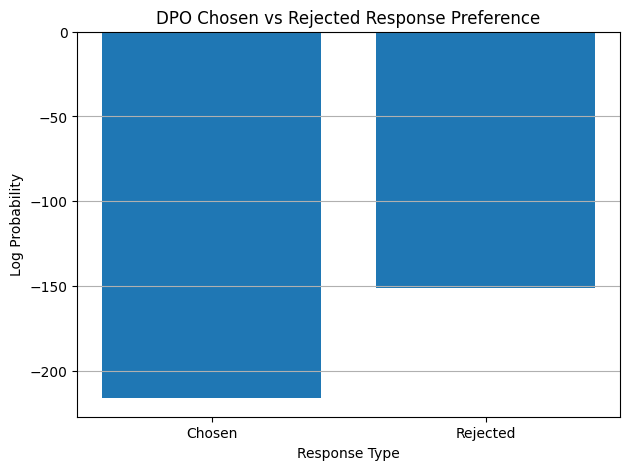

In [14]:
# Values for visualization
labels = [
    "Chosen",
    "Rejected"
]

values = [
    new_chosen.item(),
    new_rejected.item()
]

# Create bar chart
plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    values
)

plt.xlabel("Response Type")
plt.ylabel("Log Probability")

plt.title(
    "DPO Chosen vs Rejected Response Preference"
)

plt.grid(axis="y")

plt.show()

#Conclusion

A basic Direct Preference Optimization pipeline was implemented using prompt-response preference pairs. The policy model was optimized using the relative log-likelihood difference between chosen and rejected responses, while a frozen reference model provided the comparison baseline